# Answer relevance check

**Recipe 10** · Level 1 (Beginner) · Decision type: `Noul`

Judge whether a candidate response addresses the user's question so a notebook can separate relevant answers from off-topic replies.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S04: [TypeSafe AI: How to build with TypeSafe](https://docs.typesafe.ai/concepts/how-to-build-with-system-one)
- S06: [TypeSafe AI: Cookbooks](https://docs.typesafe.ai/cookbooks)

## What you will build

A relevance check for a search-and-retrieval pipeline: Jev reads one user question alongside one candidate response and answers a single yes/no proposition, "this response addresses the question the user actually asked." Python owns everything else: the question and response text, an identifier that never reaches the model, the business threshold that turns a probability into a relevant/not-relevant decision, and a separate certainty gate that sends a pair to an explicit review outcome when the probability is too close to an even split to trust either way. The notebook shows four typed answers up close -- a clearly relevant pair, a clearly off-topic pair, a pair that is only partly relevant, and a pair where a fluent, confident-sounding response answers a different question from the one asked -- then the rule, then an evaluation that reports precision and recall across a full threshold sweep, and the coverage, accuracy and risk the frozen certainty gate actually buys.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 48 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definition and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    evaluate_selective,
    evaluate_threshold,
    noul_confidence,
    select_confidence_threshold,
    select_threshold,
    threshold_sweep,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.simulation import ReviewQueue
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_threshold_sweep,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
questions = helpers.build_questions()
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number, in text or in a figure.
selection = " (a selection step, not a reported result)"

# Every one of the 48 pairs in fixtures/ needs at most one request. This cache makes sure a pair
# that is shown individually and later scored in its split is decided once, so the whole
# notebook makes exactly 48 requests in live mode, never more.
answered = {}


def decide(example):
    if example.id not in answered:
        answered[example.id] = backend.decide(helpers.build_state(example.fields), questions)[
            "relevant"
        ]
    return answered[example.id]


run_header(
    10,
    "Answer relevance check",
    backend=backend,
    n_examples=len(scored),
)

Recipe 10: Answer relevance check
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 46 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: a `pair_id`, the user's `question`, and the candidate `response`. `build_state` passes on the question and the response only; the identifier stays in Python and is attached to the outcome at the end, so it never passes through the model and every result still traces back to its pair.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-relevant"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "pair_id": "AR3001",
  "question": "What is your return policy for opened items?",
  "response": "Opened items can be returned within 30 days of delivery, as long as they still work and are not damaged; we refund the full purchase price minus the original shipping fee."
}
Jev sees:
{
  "question": "What is your return policy for opened items?",
  "response": "Opened items can be returned within 30 days of delivery, as long as they still work and are not damaged; we refund the full purchase price minus the original shipping fee."
}


## The questions

There is one proposition, and it asks one thing: does this response address the question the user actually asked? `Noul` fits because the proposition is either true or false of a given pair ([S02](https://docs.typesafe.ai/primitives)). It is written as a statement (`helpers.STATEMENT`), not a question, because CONTRIBUTING.md holds `Noul` propositions to a stricter form than TypeSafe's own documentation shows. "Actually asked" carries the weight of this recipe's hardest case: a response that is fluent and on-topic for the general subject, but answers a different question than the one in front of it, is exactly the near miss this wording is written to exclude -- a relevance check that only measured fluency or topic overlap would be fooled by it.

A Noul answer has no `confidence` field in the API response at all, unlike `Choice` and `Score`. `jev_cookbook.evaluation.noul_confidence` supplies one anyway: per the TypeSafe confidence page ([S03](https://docs.typesafe.ai/confidence)), a Noul's certainty is the Choice confidence formula, `(p_max - 1/n) / (1 - 1/n)`, applied to a yes-or-no choice (`n = 2`), which works out to `|2p - 1|` -- the distance of the probability from an even split, doubled so it still runs from 0 (`p = 0.5`, pure guess) to 1 (`p = 0` or `p = 1`, as sure as the model gets). "Python's part" below uses this certainty as an independent gate, separate from the business threshold that decides relevant or not relevant.

In [3]:
proposition = questions["relevant"]
print(proposition.instructions)
for name, description in proposition.criteria.items():
    print(f"{name}: {description}")

This response addresses the question the user actually asked.
true: The response engages with what the user is actually asking, and gives information a reader could use to answer their question -- even if the answer is brief, incomplete, or only partly covers what was asked. A response that confirms, explains, or resolves the real ask counts as addressing it, however it is phrased.
false: The response does not engage with what the user is actually asking. This covers a reply that is fluent and on-topic for the general subject but actually answers a different question, a generic or templated reply with no information specific to this question, a reply that only repeats the question back, a reply that deflects or hedges without giving an answer, and a reply about an unrelated subject entirely.


## One answer up close

Before any aggregate number, look at four typed answers: a response that clearly addresses its question, one that is clearly off-topic, one that only partly addresses what was asked, and one where the stored answer and the gold label disagree. Each answer holds just the probability that the response addresses the question and a `provenance` line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call.

What is your return policy for opened items?
Opened items can be returned within 30 days of delivery, as long as they still work and are not damaged; we refund the full purchase price minus the original shipping fee.
Noul: 0.90 probability of yes (0 is no, 1 is yes)
Provenance: synthetic


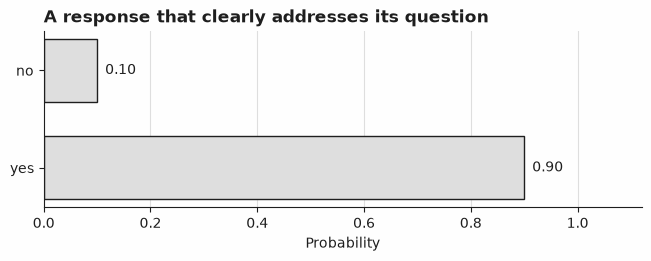

In [4]:
relevant_example = demo["d01-relevant"]
relevant_answer = decide(relevant_example)
print(relevant_example.fields["question"])
print(relevant_example.fields["response"])
show_answer(relevant_answer)
plot_answer_probabilities(relevant_answer, title="A response that clearly addresses its question")

The return-policy question gets a response that states the window, the condition, and the refund amount in one reading. The stored answer puts the probability of yes at 0.90, close to the top of the scale, so both the business threshold and the certainty gate below will treat it the same way: relevant, with nothing for a person to double-check.

In [5]:
offtopic_example = demo["d02-offtopic"]
offtopic_answer = decide(offtopic_example)
print(offtopic_example.fields["question"])
print(offtopic_example.fields["response"])
show_answer(offtopic_answer)

How do I reset my account password?
You can download your invoice history as a PDF from the Billing tab.
Noul: 0.04 probability of yes (0 is no, 1 is yes)
Provenance: synthetic


"How do I reset my account password?" gets a response about downloading invoice history -- a real feature of the product, just not an answer to anything this user asked. The stored probability, 0.04, sits near the bottom of the scale: a response can be fluent and true of the product and still not address the question in front of it.

In [6]:
partial_example = next(e for e in examples if e.id == "v18-partial")
partial_answer = decide(partial_example)
print(partial_example.fields["question"])
print(partial_example.fields["response"])
show_answer(partial_answer)

Is the product warranty transferable to a new owner?
The warranty lasts two years from the original purchase date and covers manufacturing defects.
Noul: 0.47 probability of yes (0 is no, 1 is yes)
Provenance: synthetic


"Is the product warranty transferable to a new owner?" gets a response that is clearly *about* the warranty -- its length, what it covers -- and never says a word about whether it transfers. A reader skimming for "is this about the warranty" would call it relevant; a reader checking whether it actually answers what was asked would not, and this recipe's gold label is false. The stored probability, 0.47, sits almost exactly on an even split: this is one of four pairs in this recipe's fixtures held deliberately within 0.09 of 0.5, with gold labels split both ways (two true, two false), so that a pair's probability alone does not reliably say which way it should go. "Python's part" below is where a pair this close gets a third option instead of a forced guess.

In [7]:
hard_example = next(e for e in examples if e.id == "v22-hard-wrong")
hard_answer = decide(hard_example)
print(hard_example.fields["question"])
print(hard_example.fields["response"])
show_answer(hard_answer)

How do I reset my account password?
To change the email address linked to your account, open Account Settings, select 'Email', and confirm the new address from the link we send you.
Noul: 0.78 probability of yes (0 is no, 1 is yes)
Provenance: synthetic


"How do I reset my account password?" gets a response that is complete, fluent, and confident -- about changing the email address on the account instead. It even opens with the same "Open Account Settings" phrasing a real password-reset answer would use, which is exactly what makes it a hard case: a relevance check that only looked at fluency and topical overlap (account settings, a security-adjacent action) would call this a strong match. This recipe's gold label is false. The stored answer calls it confidently true at 0.78 -- far from an even split, but, as "Python's part" below works out, not quite far enough to clear the certainty gate `validation` ends up choosing, so this particular pair is sent to review rather than slipping through. That is not the gate recognising the answer is wrong; certainty measures how far a probability leans, not whether it leans the right way, and `test` carries a near-identical hard case (`t22-hard-wrong`) whose stored probability lands just on the other side of that same frozen cut-off.

## Python's part

Jev supplies the probability; what happens with it is code. `check_relevance` in `helpers.py` decides one of three outcomes for a pair, and CONTRIBUTING.md section 4 requires the third: "Uncertain or inconsistent results go to an explicit review outcome." A pair whose certainty (`noul_confidence`, "The questions" above) does not clear `min_confidence` goes to `REVIEW`, whichever way its probability leans -- the mid-range TypeSafe's own Noul documentation routes to a person. Only once a pair clears that gate does the business `threshold` decide `RELEVANT` or `NOT_RELEVANT`. `tests/test_helpers.py` pins this as a general property with an isolated example (a pair stored at `noul = 0.95`, far past any threshold this recipe chooses): certainty alone cannot tell a confidently wrong answer from a confidently right one, so a high enough certainty still reaches `RELEVANT` rather than being quietly excused into `REVIEW`. Whether any particular pair's own certainty clears the specific cut-off chosen below is a different question, with a different answer for `v22-hard-wrong` (shown above) and for `test`'s near-identical `t22-hard-wrong`, as the cells after the one below show.

Both thresholds are chosen here, on `validation`, and then frozen for the rest of this notebook. `select_threshold` sweeps every observed probability as a candidate business cut-off and picks the one with the highest `f1` (the harmonic mean of precision and recall, explained below). `select_confidence_threshold` then sweeps every observed certainty value and picks the lowest one whose answered pairs are all correct on `validation` -- a business choice (never knowingly act on a pair this rule got wrong, as measured here) stated as `target_accuracy=1.0`, not a property of the data. Because `v22-hard-wrong` is the only pair `validation`'s raw business decision gets wrong, reaching that target means excluding it specifically, which is exactly what happens below. Applying both thresholds, frozen, to the four answers shown above shows all three outcomes the rule can produce. Before freezing it, `docs/evaluation.md`'s "Noul three-path pattern" warns to check `selective_curve(raw_correct, val_confidence)` first: if accuracy never falls as coverage rises, certainty is not separating right from wrong on this data and the gate buys nothing. It does fall here, which is what justifies gating on it at all. The same page also notes that `|2p - 1|` is distance from 0.5, not distance from `threshold`: it would read a pair near 0.5 as uncertain even if `threshold` sat elsewhere, which matters less here only because this recipe's frozen threshold (below) happens to land close to 0.5 itself.

In [8]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]
val_noul = [a.noul for a in val_answers]
threshold = select_threshold(val_gold, val_noul, objective="f1")
print(f"business threshold, frozen from here on: {threshold:.2f}{selection}")

# The certainty gate is chosen from the business decision alone (`is_relevant`, ignoring any
# review), the same way recipe 01 chooses its confidence threshold from the raw Choice: what
# would check_relevance() decide with no gate at all, and was that decision right?
would_be_relevant = [n >= threshold for n in val_noul]
raw_correct = [r == g for r, g in zip(would_be_relevant, val_gold, strict=True)]
val_confidence = noul_confidence(val_noul)
min_confidence = select_confidence_threshold(raw_correct, val_confidence, target_accuracy=1.0)
print(f"certainty threshold, frozen from here on: {min_confidence:.2f}{selection}")

for shown_example, shown_answer in (
    (relevant_example, relevant_answer),
    (offtopic_example, offtopic_answer),
    (partial_example, partial_answer),
    (hard_example, hard_answer),
):
    result = helpers.check_relevance(
        shown_example.fields["pair_id"], shown_answer, threshold, min_confidence
    )
    print(f"{result.pair_id}: noul {shown_answer.noul:.2f} -> {result.outcome} ({result.reason})")

business threshold, frozen from here on: 0.55 (a selection step, not a reported result)
certainty threshold, frozen from here on: 0.64 (a selection step, not a reported result)
AR3001: noul 0.90 -> relevant (noul at or above the threshold: the response addresses it)
AR3002: noul 0.04 -> not_relevant (noul below the threshold: the response does not address it)
AR1018: noul 0.47 -> review (too close to an even split to trust either way: needs a person)
AR1022: noul 0.78 -> review (too close to an even split to trust either way: needs a person)


`jev_cookbook.simulation.ReviewQueue` is the shared primitive for the person this rule routes an uncertain pair to (`docs/simulation.md`): `submit` records an item, the reason it was sent, and the typed answer behind that reason, and nothing in it executes anything. Only the `REVIEW` outcome belongs there -- a `RELEVANT` response is shown to the user and a `NOT_RELEVANT` one is suppressed, and neither needs a person, while a reviewed pair genuinely does. This cell builds the one queue the rest of this notebook uses, from the four pairs decided just above. Two of them clear the certainty gate outright, one each way (the clearly relevant and the clearly off-topic pair). The other two both land in the queue, for the same mechanical reason even though only one of them is the kind of case the gate is meant to catch: `v18-partial` genuinely sits near an even split, and `v22-hard-wrong` is confidently wrong but, as it happens, not confidently enough to clear this particular cut-off.

In [9]:
queue = ReviewQueue()
for example, answer_ in (
    (relevant_example, relevant_answer),
    (offtopic_example, offtopic_answer),
    (partial_example, partial_answer),
    (hard_example, hard_answer),
):
    result = helpers.check_relevance(example.fields["pair_id"], answer_, threshold, min_confidence)
    if result.outcome == helpers.REVIEW:
        queue.submit({"pair_id": result.pair_id}, result.reason, answer=answer_)
print(f"{len(queue)} items queued so far{selection}")
for item in queue.to_dicts():
    print(item["item"], "--", item["reason"])

2 items queued so far (a selection step, not a reported result)
{'pair_id': 'AR1018'} -- too close to an even split to trust either way: needs a person
{'pair_id': 'AR1022'} -- too close to an even split to trust either way: needs a person


## Evaluation

Both thresholds were chosen and frozen above, on `validation`. This section reports what the frozen rule does: `helpers.check_relevance` is applied to every example in `validation` and in `test`, and the counts below come from what it actually returns, not from a separate reimplementation of the same conditions -- including the selective-prediction numbers further down, which read `check_relevance`'s own `is_relevant` field rather than re-checking `noul >= threshold`. Alongside that, `jev_cookbook.evaluation` reports precision and recall across the full threshold sweep and the coverage, accuracy and risk the certainty gate actually buys. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number and figure, in every run mode, is a selection step rather than a reported result, which is why it carries a different label.

In [10]:
def report(chosen, decided, gold, threshold, min_confidence):
    """Apply check_relevance to every answer and tally what it actually did."""
    results = [
        helpers.check_relevance(e.fields["pair_id"], a, threshold, min_confidence)
        for e, a in zip(chosen, decided, strict=True)
    ]
    counts = {helpers.RELEVANT: 0, helpers.REVIEW: 0, helpers.NOT_RELEVANT: 0}
    right_relevant = 0
    for r, g in zip(results, gold, strict=True):
        counts[r.outcome] += 1
        if r.outcome == helpers.RELEVANT and g:
            right_relevant += 1
    return results, counts, right_relevant


val_results, val_counts, val_right_relevant = report(
    val_examples, val_answers, val_gold, threshold, min_confidence
)
print(f"validation, {len(val_examples)} examples{selection}")
print(f"judged relevant: {val_counts[helpers.RELEVANT]}{selection}")
print(
    f"  right among those judged relevant: {val_right_relevant} of "
    f"{val_counts[helpers.RELEVANT]}{selection}"
)
print(f"sent to review (too uncertain): {val_counts[helpers.REVIEW]}{selection}")
print(f"judged not relevant: {val_counts[helpers.NOT_RELEVANT]}{selection}")

validation, 23 examples (a selection step, not a reported result)
judged relevant: 10 (a selection step, not a reported result)
  right among those judged relevant: 10 of 10 (a selection step, not a reported result)
sent to review (too uncertain): 5 (a selection step, not a reported result)
judged not relevant: 8 (a selection step, not a reported result)


`precision` is the fraction of pairs judged relevant that were actually relevant, and `recall` is the fraction of the real relevant pairs in this split the rule found at all; `f1` is their harmonic mean, a single number that is low whenever either one is. These are computed on the business decision alone, before the certainty gate removes anything. The chart below sweeps every threshold `select_threshold` considered on `validation` -- and it carries the `selection` label too, in every run mode, because a figure drawn from `validation` is exactly as much a selection step as a printed number.

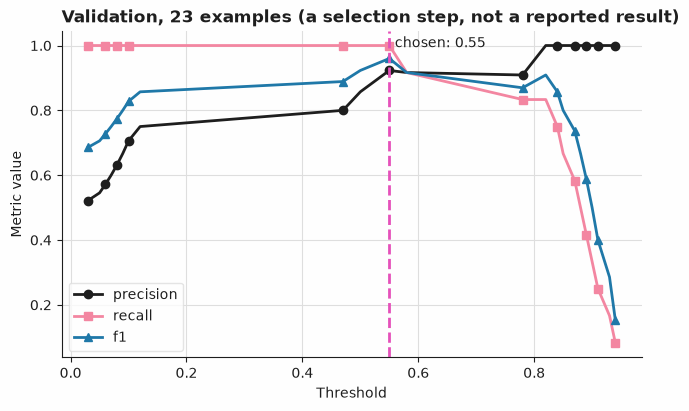

In [11]:
sweep = threshold_sweep(val_gold, val_noul)
plot_threshold_sweep(
    sweep, chosen=threshold, title=f"Validation, {len(val_examples)} examples{selection}"
)

`test` is used once, after both thresholds are frozen. `evaluate_threshold` reports the same precision, recall and `f1` at exactly the business threshold on `test`, ignoring the certainty gate entirely -- these numbers describe what the threshold alone would do if every pair were decided automatically. `evaluate_selective` then reports what the certainty gate actually buys, using `is_relevant` (from `check_relevance`, never recomputed) as the fixed decision and `noul_confidence` as the independent signal that gates it: `coverage` is the fraction of `test` pairs the gate lets through without review; `accuracy` is the fraction of those whose business decision matched the gold label; and `risk` is its complement, `1 - accuracy`, the fraction of ungated decisions that turn out wrong. Because a decision Python acts on without a person goes straight to showing the response or suppressing it, `risk` is the number that matters to whoever relies on that.

In [12]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]
test_noul = [a.noul for a in test_answers]

test_results, test_counts, test_right_relevant = report(
    test_examples, test_answers, test_gold, threshold, min_confidence
)
point = evaluate_threshold(test_gold, test_noul, threshold)
print(f"test, {len(test_examples)} examples, both thresholds frozen{check}")
print(f"judged relevant: {test_counts[helpers.RELEVANT]}{check}")
print(
    f"  right among those judged relevant: {test_right_relevant} of "
    f"{test_counts[helpers.RELEVANT]}{check}"
)
print(f"sent to review (too uncertain): {test_counts[helpers.REVIEW]}{check}")
print(f"judged not relevant: {test_counts[helpers.NOT_RELEVANT]}{check}")
print(f"precision {point.precision:.3f}  recall {point.recall:.3f}  f1 {point.f1:.3f}{check}")

# is_relevant comes from check_relevance()'s own output -- the business decision it already
# made -- never recomputed here as `noul >= threshold`.
test_is_relevant = [r.is_relevant for r in test_results]
test_correct = [p == g for p, g in zip(test_is_relevant, test_gold, strict=True)]
test_confidence = noul_confidence(test_noul)
selective = evaluate_selective(test_correct, test_confidence, min_confidence)
print(
    f"coverage {selective.coverage:.3f} "
    f"(ungated {selective.n_answered} of {selective.n_total}){check}"
)
print(f"accuracy among ungated decisions {selective.accuracy:.3f}{check}")
print(f"risk among ungated decisions {selective.risk:.3f}{check}")

test, 23 examples, both thresholds frozen (a pipeline check, not a Jev result)
judged relevant: 11 (a pipeline check, not a Jev result)
  right among those judged relevant: 10 of 11 (a pipeline check, not a Jev result)
sent to review (too uncertain): 4 (a pipeline check, not a Jev result)
judged not relevant: 8 (a pipeline check, not a Jev result)
precision 0.923  recall 1.000  f1 0.960 (a pipeline check, not a Jev result)
coverage 0.826 (ungated 19 of 23) (a pipeline check, not a Jev result)
accuracy among ungated decisions 0.947 (a pipeline check, not a Jev result)
risk among ungated decisions 0.053 (a pipeline check, not a Jev result)


The one pair `test` gets wrong among those judged relevant is `t22-hard-wrong` -- far enough from an even split that the certainty gate lets it straight through, and above the business threshold, so the response is treated as relevant even though the gold label is false. That one error is the risk figure above. The rule sends four pairs to review instead of deciding automatically: `t18-partial` and `t20-partial` (both actually not relevant) and `t19-partial` and `t21-partial` (both actually relevant); all four sit close enough to an even split that the certainty gate cannot tell which ones are the real risk, so all four go to a person and none counts against `risk` or against `precision`/`recall` either way -- `check_relevance`'s outcome does not change what the raw business decision *would* have been, it only changes whether Python acts on it alone. Neither frozen number is a guarantee about anything but this fixture set: a threshold and a certainty gate chosen on `validation` are a trade-off measured there, not a promise about `test` or about any pair this recipe has not seen -- which is why `validation`'s own counts are reported above too, rather than only the clean parts of this story.

The same queue from "Python's part" now gets every `validation` and `test` pair `check_relevance` sent to `REVIEW` that is not already in it, so it reflects the whole run rather than the four pairs shown up close.

In [13]:
already_queued = {partial_example.id, hard_example.id}  # decided, and queued, just above
for example, answer_, result in zip(
    val_examples + test_examples,
    val_answers + test_answers,
    val_results + test_results,
    strict=True,
):
    if result.outcome == helpers.REVIEW and example.id not in already_queued:
        queue.submit({"pair_id": result.pair_id}, result.reason, answer=answer_)

by_reason = {}
for item in queue.to_dicts():
    by_reason[item["reason"]] = by_reason.get(item["reason"], 0) + 1
print(f"{len(queue)} items in the queue across both scored splits{check}")
for reason, count in sorted(by_reason.items()):
    print(f"  {count} because: {reason}{check}")

9 items in the queue across both scored splits (a pipeline check, not a Jev result)
  9 because: too close to an even split to trust either way: needs a person (a pipeline check, not a Jev result)


## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule, the queue and the evaluation behave as designed on 46 scored pairs (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, some of them wrong on purpose -- including, on each split, one response that is wrong and far from an even split. `validation`'s own copy of that case is exactly what the certainty gate chosen above has to exclude to reach its target; `test`'s near-identical copy happens to sit on the other side of that same frozen cut-off, which is where this recipe's non-zero risk figure actually comes from. Every number above describes this fixture set and not a model.

In [14]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard pair to `ROWS` in `build_fixtures.py` with the probability you expect a model might give, run `python build_fixtures.py`, and see where `check_relevance` sends it, and whether the queue picks it up.
- Change `select_confidence_threshold`'s `target_accuracy` and see how many pairs go to review instead of being decided outright.
- Neighbouring recipes: [`02-refund-intent-detection`](../02-refund-intent-detection/) (another `Noul` proposition with the same three-path pattern) and [`08-faq-selection`](../08-faq-selection/) (a `Choice` question over the same kind of candidate-response search), both in `Search & retrieval` alongside this recipe.